In [53]:
import yfinance as yf
import pandas as pd
import numpy as np
import math
import os
import json
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import Input, Concatenate

In [54]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/bbva_enriched.csv")
df.head()

,Unnamed: 0.1,Unnamed: 1,Unnamed: 2,Unnamed: 0,Date,SAN_Price,BBVA_Adj_Close,BBVA_Close,BBVA_Volume,BBVA_High,BBVA_Low,BBVA_Open,IBEX,SP500,EURUSD,OIL,eventos_negativos
0,0,2.0,4.0,6,2003-12-10,7.616409,3.272072,9.799588,20620681,9.847626,9.655477,9.799588,7358.799805,1059.050049,1.219096,31.879999,0
1,1,3.0,5.0,7,2003-12-11,7.711614,3.307359,9.905270,21052367,9.905270,9.741944,9.905270,7432.200195,1071.209961,1.222404,31.850000,0
2,2,4.0,6.0,8,2003-12-12,7.711614,3.297734,9.876448,17599306,9.991737,9.828411,9.876448,7434.399902,1074.140015,1.227898,33.040001,0
3,3,5.0,7.0,9,2003-12-15,7.737579,3.310567,9.914878,26816896,10.020559,9.876448,9.914878,7471.799805,1068.040039,1.231997,33.180000,0
4,4,6.0,8.0,10,2003-12-16,7.694304,3.339438,10.001345,20469765,10.020559,9.828411,10.001345,7487.000000,1075.130005,1.232195,32.889999,0


In [55]:
# leer sin cabecera porque las tres primeras filas son especiales
df_raw = pd.read_csv("../csv/bbva_enriched.csv", header=None)

# 1) la primera fila tiene los nombres buenos
column_names = df_raw.iloc[0].tolist()

# 2) nos quedamos con los datos reales (a partir de la fila 3 → índice 3)
df = df_raw.iloc[3:].reset_index(drop=True)

# 3) ponemos los nombres de columna
df.columns = column_names

# 4) renombrar 'Price' -> 'Date' (porque es la fecha en realidad)
df = df.rename(columns={"Price": "Date"})

# 5) convertir Date a datetime
df["Date"] = pd.to_datetime(df["Date"])

# 6) pasar el resto a numérico
for col in df.columns:
    if col != "Date":
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.head())
print(df.dtypes)

df.to_csv("../csv/bbva_enriched.csv")
print("💾 Archivo guardado: 'csv/bbva_enriched.csv'")

   NaN  NaN   NaN  Unnamed: 0       Date  SAN_Price  BBVA_Adj_Close  \
0  2.0  4.0   6.0           8 2003-12-12   7.711614        3.297734   
1  3.0  5.0   7.0           9 2003-12-15   7.737579        3.310567   
2  4.0  6.0   8.0          10 2003-12-16   7.694304        3.339438   
3  5.0  7.0   9.0          11 2003-12-17   7.737579        3.345854   
4  6.0  8.0  10.0          12 2003-12-18   7.798164        3.390765   

   BBVA_Close  BBVA_Volume  BBVA_High  BBVA_Low  BBVA_Open         IBEX  \
0    9.876448     17599306   9.991737  9.828411   9.876448  7434.399902   
1    9.914878     26816896  10.020559  9.876448   9.914878  7471.799805   
2   10.001345     20469765  10.020559  9.828411  10.001345  7487.000000   
3   10.020559     21371349  10.030167  9.914878  10.020559  7506.299805   
4   10.155064     20464585  10.155064  9.953307  10.155064  7585.500000   

         SP500    EURUSD        OIL  eventos_negativos  
0  1074.140015  1.227898  33.040001                  0  
1  1068.

In [56]:
# 1. leer normal (una sola cabecera)
df = pd.read_csv("../csv/bbva_enriched.csv")
df.head()

,Unnamed: 0.1,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 0,Date,SAN_Price,BBVA_Adj_Close,BBVA_Close,BBVA_Volume,BBVA_High,BBVA_Low,BBVA_Open,IBEX,SP500,EURUSD,OIL,eventos_negativos
0,0,2.0,4.0,6.0,8,2003-12-12,7.711614,3.297734,9.876448,17599306,9.991737,9.828411,9.876448,7434.399902,1074.140015,1.227898,33.040001,0
1,1,3.0,5.0,7.0,9,2003-12-15,7.737579,3.310567,9.914878,26816896,10.020559,9.876448,9.914878,7471.799805,1068.040039,1.231997,33.180000,0
2,2,4.0,6.0,8.0,10,2003-12-16,7.694304,3.339438,10.001345,20469765,10.020559,9.828411,10.001345,7487.000000,1075.130005,1.232195,32.889999,0
3,3,5.0,7.0,9.0,11,2003-12-17,7.737579,3.345854,10.020559,21371349,10.030167,9.914878,10.020559,7506.299805,1076.479980,1.240202,33.349998,0
4,4,6.0,8.0,10.0,12,2003-12-18,7.798164,3.390765,10.155064,20464585,10.155064,9.953307,10.155064,7585.500000,1089.180054,1.242298,33.709999,0


In [57]:
# 1) cargar
df = pd.read_csv("../csv/bbva_enriched.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# 2) quitar columnas que sobran
cols_to_drop = ["Unnamed: 0"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

# 3) definir grupos de columnas
fin_cols = [
    "BBVA_Adj_Close", "BBVA_Close", "BBVA_Volume", "BBVA_High",
    "BBVA_Low", "BBVA_Open", "SAN_Price", "IBEX", "SP500", "EURUSD", "OIL"
]
macro_like = [
    "gdp_growth_x", "gdp_growth_y",
    "hicp_es", "hicp_es_yoy", "hicp_es_gap_ecb",
    "ecb_refi_rate", "ecb_refi_rate_diff",
    "bce_hike", "bce_hike_strict",
    "house_price_index_es"
]
bin_like = ["eventos_negativos"]

fin_cols = [c for c in fin_cols if c in df.columns]
macro_like = [c for c in macro_like if c in df.columns]
bin_like = [c for c in bin_like if c in df.columns]

# 4) rellenar financieras
df[fin_cols] = df[fin_cols].interpolate(method="linear", limit_direction="both")

# 5) rellenar macro
df[macro_like] = df[macro_like].ffill().bfill()

# 6) binarias
for c in bin_like:
    df[c] = df[c].fillna(0)

# 7) lo que quede
for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].fillna(0)

print("NaN totales después de rellenar:", df.isna().sum().sum())

# dejamos la fecha como índice
df = df.set_index("Date")


NaN totales después de rellenar: 0


In [58]:
# asumimos que ya tienes estas columnas:
# BBVA_Open, BBVA_High, BBVA_Low, BBVA_Close

df["day_range"] = df["BBVA_High"] - df["BBVA_Low"]
df["close_vs_open"] = df["BBVA_Close"] - df["BBVA_Open"]

# evitar división por cero
eps = 1e-6
df["close_pos_in_range"] = (df["BBVA_Close"] - df["BBVA_Low"]) / (
    (df["BBVA_High"] - df["BBVA_Low"]) + eps
)

# sombras (opcionales)
df["upper_shadow"] = df["BBVA_High"] - df[["BBVA_Open", "BBVA_Close"]].max(axis=1)
df["lower_shadow"] = df[["BBVA_Open", "BBVA_Close"]].min(axis=1) - df["BBVA_Low"]

In [59]:
def preparar_datos_multivariados(df, target_col="BBVA_Close", window_size=25):
    df = df.sort_index()

    selected_features = [
    "BBVA_Open",
    "BBVA_High",
    "BBVA_Low",
    "BBVA_Volume",
    "SAN_Price",
    "eventos_negativos",
]

    feature_cols = [c for c in selected_features if c in df.columns]
    features = df[feature_cols].copy()
    target = df[[target_col]].copy()

    X, y = [], []
    for i in range(window_size, len(features)):
        X.append(features.iloc[i-window_size:i].values)
        y.append(target.iloc[i].values[0])

    return np.array(X), np.array(y), feature_cols

In [60]:
X, y, feature_cols = preparar_datos_multivariados(
    df,
    target_col="BBVA_Close",
    window_size=25
)
print(X.shape, y.shape)
print(feature_cols)

(5379, 25, 6) (5379,)
['BBVA_Open', 'BBVA_High', 'BBVA_Low', 'BBVA_Volume', 'SAN_Price', 'eventos_negativos']


In [61]:
# split temporal
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# =============== ESCALADO CORRECTO ===============
n_timesteps = X_train.shape[1]
n_features = X_train.shape[2]

# re-formatear para escalar por feature
X_train_2d = X_train.reshape(-1, n_features)
X_test_2d  = X_test.reshape(-1, n_features)

scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(-1, n_timesteps, n_features)
X_test_scaled  = scaler_X.transform(X_test_2d).reshape(-1, n_timesteps, n_features)

# target
y_train = y_train.reshape(-1, 1)
y_test  = y_test.reshape(-1, 1)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)

Train: (4303, 25, 6) (4303,)
Test : (1076, 25, 6) (1076,)


In [62]:
def build_lstm_skip(window_size, n_features):
    seq_input = Input(shape=(window_size, n_features))
    x = LSTM(48, return_sequences=True, dropout=0.05, recurrent_dropout=0.05)(seq_input)
    x = LSTM(32, dropout=0.05, recurrent_dropout=0.05)(x)
    x = Dense(32, activation="relu")(x)
    last_step = seq_input[:, -1, :]
    x = Concatenate()([x, last_step])
    out = Dense(1)(x)
    model = Model(seq_input, out)
    model.compile(optimizer=Adam(learning_rate=1e-3), loss="mse")
    return model

In [63]:
# ==============================
# CONFIGURACIÓN BASE
# ==============================
EPOCHS_DEFAULT = 800     # un poco menos
EPOCHS_LSTM_SKIP = 1200
BATCH = 32
window_size = 25

# Crear carpeta 'modelos' fuera de notebooks si no existe
modelos_dir = os.path.join("..", "modelos")
os.makedirs(modelos_dir, exist_ok=True)

# ==============================
# FUNCIÓN DE ENTRENAMIENTO
# ==============================
def entrenar_modelo(nombre, build_fn, X_train, y_train, X_test, y_test, window_size):
    print(f"\n🧠 Entrenando modelo {nombre}...\n")
    n_features = X_train.shape[2]
    model = build_fn(window_size, n_features)

    model_path = os.path.join(modelos_dir, f"mejor_{nombre.lower()}_bbva.h5")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=150 if nombre == "LSTM_Skip" else 100,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )

    epochs = EPOCHS_LSTM_SKIP if nombre == "LSTM_Skip" else EPOCHS_DEFAULT

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=BATCH,
        validation_data=(X_test, y_test),
        callbacks=[early_stop, checkpoint],
        verbose=1
    )

    # opcional: guardar history para comparar luego
    hist_path = os.path.join(modelos_dir, f"hist_{nombre.lower()}_BBVA.json")
    with open(hist_path, "w") as f:
        json.dump(history.history, f)

    print(f"✅ Modelo {nombre} finalizado ({len(history.history['loss'])} epochs entrenadas)")
    return model, history

# ==============================
# ENTRENAR LOS TRES MODELOS
# ==============================


lstm_skip_model, hist_lstm_skip = entrenar_modelo(
    "LSTM_Skip",
    build_lstm_skip,
    X_train_scaled, y_train_scaled,
    X_test_scaled,  y_test_scaled,
    window_size
)


🧠 Entrenando modelo LSTM_Skip...

Epoch 1/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0251
Epoch 1: val_loss improved from None to 0.00433, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0109 - val_loss: 0.0043
Epoch 2/1200
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045
Epoch 2: val_loss did not improve from 0.00433
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0038 - val_loss: 0.0072
Epoch 3/1200
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0022
Epoch 3: val_loss did not improve from 0.00433
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0020 - val_loss: 0.0052
Epoch 4/1200
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0016
Epoch 4: val_loss improved from 0.00433 to 0.00262, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0014 - val_loss: 0.0026
Epoch 5/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0013
Epoch 5: val_loss did not improve from 0.00262
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 0.0026
Epoch 6/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 8.8759e-04
Epoch 6: val_loss improved from 0.00262 to 0.00227, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 8.6832e-04 - val_loss: 0.0023
Epoch 7/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7.8541e-04
Epoch 7: val_loss improved from 0.00227 to 0.00149, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.4614e-04 - val_loss: 0.0015
Epoch 8/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.4894e-04
Epoch 8: val_loss did not improve from 0.00149
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 6.4129e-04 - val_loss: 0.0025
Epoch 9/1200
131/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.8962e-04
Epoch 9: val_loss did not improve from 0.00149
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.5165e-04 - val_loss: 0.0017
Epoch 10/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.3504e-04
Epoch 10: val_loss improved from 0.00149 to 0.00133, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


...

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.1676e-04 - val_loss: 1.1598e-04
Epoch 307/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1171e-04
Epoch 307: val_loss did not improve from 0.00012
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1223e-04 - val_loss: 1.2211e-04
Epoch 308/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1919e-04
Epoch 308: val_loss did not improve from 0.00012
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1199e-04 - val_loss: 1.1619e-04
Epoch 309/1200
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1098e-04
Epoch 309: val_loss did not improve from 0.00012
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.1576e-04 - val_loss: 1.6085e-04
Epoch 310/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1342e-04
Epoch 310: val_loss did not improve from 0.00012
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1181e-04 - val_loss: 1.2345e-04
Epoch 311/1200
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0777e-04
Epoc

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1225e-04 - val_loss: 1.1509e-04
Epoch 320/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1443e-04
Epoch 320: val_loss improved from 0.00012 to 0.00011, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1233e-04 - val_loss: 1.1429e-04
Epoch 321/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1873e-04
Epoch 321: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.1330e-04 - val_loss: 1.4848e-04
Epoch 322/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.1439e-04
Epoch 322: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.1430e-04 - val_loss: 1.2156e-04
Epoch 323/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.1672e-04
Epoch 323: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 1.0969e-04 - val_loss: 1.3321e-04
Epoch 324/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0949e-04
Epoch 324: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.0997e-04 - val_loss: 1.1848e-04
Epoch 325/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.0729e-04
Epoc

135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0425e-04 - val_loss: 1.1404e-04
Epoch 382/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0559e-04
Epoch 382: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 1.0773e-04 - val_loss: 1.3907e-04
Epoch 383/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0748e-04
Epoch 383: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0589e-04 - val_loss: 1.2395e-04
Epoch 384/1200
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0424e-04
Epoch 384: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0820e-04 - val_loss: 1.1439e-04
Epoch 385/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0796e-04
Epoch 385: val_loss improved from 0.00011 to 0.00011, saving model to ..\modelos\mejor_lstm_skip_bbva.h5


135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0977e-04 - val_loss: 1.1341e-04
Epoch 386/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.1549e-04
Epoch 386: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0991e-04 - val_loss: 1.2024e-04
Epoch 387/1200
133/135 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0957e-04
Epoch 387: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0643e-04 - val_loss: 1.2743e-04
Epoch 388/1200
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0868e-04
Epoch 388: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.0602e-04 - val_loss: 1.1625e-04
Epoch 389/1200
132/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0245e-04
Epoch 389: val_loss did not improve from 0.00011
135/135 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 1.0559e-04 - val_loss: 1.1542e-04
Epoch 390/1200
134/135 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.0262e-04
Epoc

In [64]:
# ==============================
y_pred_lstm_skip = lstm_skip_model.predict(X_test_scaled)

# desescalar la y real
y_test_real = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1))

# desescalar las predicciones
pred_lstm_skip_real = scaler_y.inverse_transform(y_pred_lstm_skip)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [65]:
def evaluar(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

mae_lstm_skip, rmse_lstm_skip = evaluar(y_test_real, pred_lstm_skip_real)

print("LSTM_Skip -> MAE:", mae_lstm_skip, "RMSE:", rmse_lstm_skip)

LSTM_Skip -> MAE: 0.12707067976210634 RMSE: 0.18244060720269364


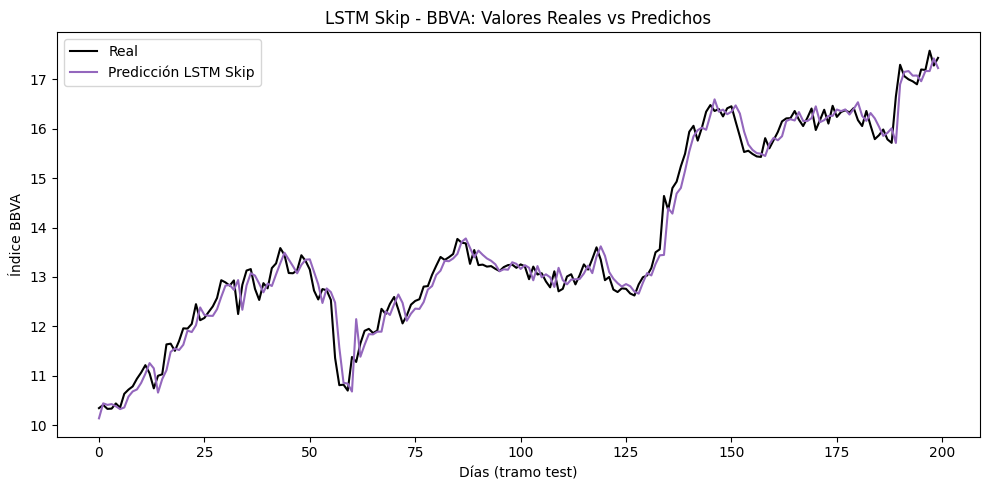

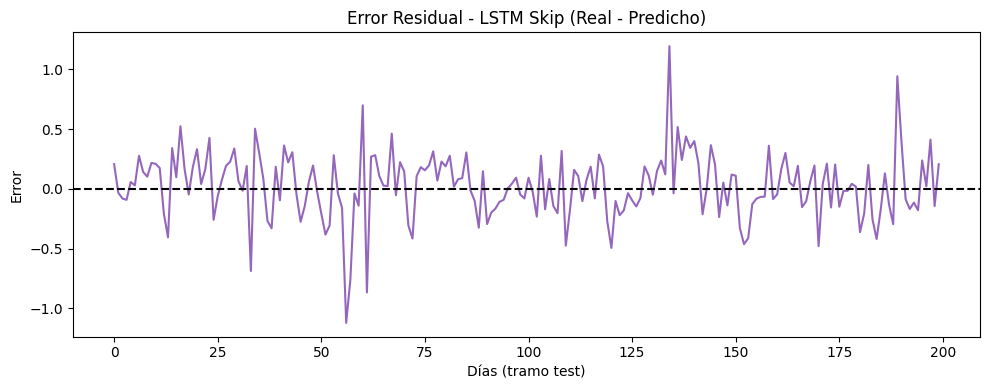

In [66]:
# --- Tramo a mostrar (últimos 200 días del test, por ejemplo) ---
n_mostrar = 200
y_real_plot = y_test_real[-n_mostrar:]
pred_lstm_skip_plot = pred_lstm_skip_real[-n_mostrar:]

# ===============================
#  LSTM Skip
# ===============================
plt.figure(figsize=(10,5))
plt.plot(y_real_plot, label="Real", color="black")
plt.plot(pred_lstm_skip_plot, label="Predicción LSTM Skip", color="tab:purple")
plt.title("LSTM Skip - BBVA: Valores Reales vs Predichos")
plt.xlabel("Días (tramo test)")
plt.ylabel("Índice BBVA")
plt.legend()
plt.tight_layout()
plt.show()
# --- Error LSTM Skip ---
plt.figure(figsize=(10,4))
plt.plot(y_real_plot - pred_lstm_skip_plot, color="tab:purple")
plt.axhline(0, color="black", linestyle="--")
plt.title("Error Residual - LSTM Skip (Real - Predicho)")
plt.xlabel("Días (tramo test)")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

In [67]:
def predecir_siguiente_multivariante(model, df_original, feature_cols, scaler_X, scaler_y, target_col="BBVA_Close", window_size=25):
    """
    Predice el siguiente valor del target_col usando LAS MISMAS feature_cols que en el entrenamiento.
    """
    # 1) nos quedamos solo con las columnas que realmente usó el modelo
    features = df_original[feature_cols].copy()

    # 2) tomamos los últimos window_size pasos
    ultimos = features.values[-window_size:]

    # 3) escalar
    ultimos_scaled = scaler_X.transform(ultimos)

    # 4) forma (1, window_size, n_features)
    X_input = ultimos_scaled.reshape((1, window_size, len(feature_cols)))

    # 5) predecir en escala 0-1
    pred_scaled = model.predict(X_input)

    # 6) desescalar
    pred_real = scaler_y.inverse_transform(pred_scaled)

    return pred_real[0, 0]


def predecir_n_dias(model, df_original, feature_cols, scaler_X, scaler_y, n_dias=5, target_col="BBVA_Close", window_size=25):
    """
    Hace predicción recursiva n_dias hacia delante.
    Devuelve una lista con las predicciones reales.
    """
    # trabajamos sobre una copia para no tocar el df original
    df_temp = df_original.copy()
    predicciones = []

    for i in range(n_dias):
        siguiente = predecir_siguiente_multivariante(
            model,
            df_temp,
            feature_cols,
            scaler_X,
            scaler_y,
            target_col=target_col,
            window_size=window_size
        )
        predicciones.append(siguiente)

        # añadir ese día “futuro” al df_temp para que el siguiente paso tenga contexto
        # aquí ponemos el target en la columna target, y para el resto de features
        # usamos el último valor (hold) porque no los conocemos en el futuro
        nueva_fila = df_temp.iloc[-1].copy()
        nueva_fila[target_col] = siguiente
        # IMPORTANTÍSIMO: también actualizar las features derivadas si las usas
        df_temp = pd.concat([df_temp, nueva_fila.to_frame().T], ignore_index=True)

    return predicciones


# ====== USO ======
# suponiendo que ya tienes:
# - df (con tus columnas)
# - feature_cols (las que usaste al entrenar)
# - scaler_X, scaler_y
# - lstm_skip_model (o rnn_model, el que quieras)

preds_5 = predecir_n_dias(
    model=lstm_skip_model,
    df_original=df.reset_index(drop=False),   # por si está con Date como índice
    feature_cols=feature_cols,
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    n_dias=5,
    target_col="BBVA_Close",
    window_size=20   # o 25 según tu modelo
)

print("Predicciones próximos 5 días:")
for i, p in enumerate(preds_5, 1):
    print(f"Día +{i}: {p:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicciones próximos 5 días:
Día +1: 17.5546
Día +2: 17.5327
Día +3: 17.5220
Día +4: 17.5221
Día +5: 17.5222


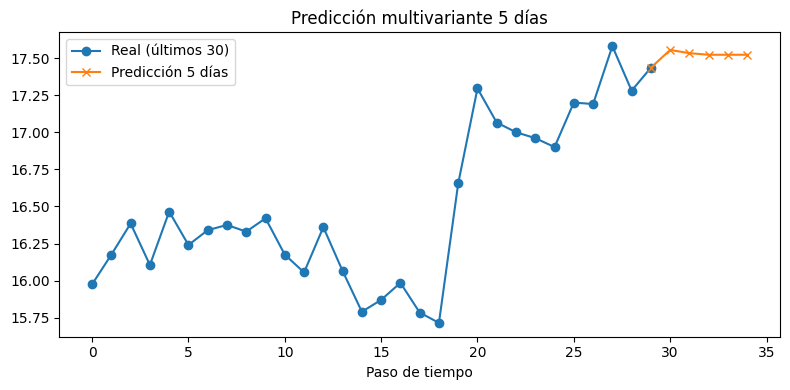

In [68]:
# últimos 30 días reales
ultimos_reales = df["BBVA_Close"].tail(30).values

# concatenar para graficar
serie_completa = np.concatenate([ultimos_reales, np.array(preds_5)])

plt.figure(figsize=(8,4))
plt.plot(range(len(ultimos_reales)), ultimos_reales, label="Real (últimos 30)", marker="o")
plt.plot(range(len(ultimos_reales)-1, len(serie_completa)), serie_completa[len(ultimos_reales)-1:],
         label="Predicción 5 días", marker="x")
plt.legend()
plt.title("Predicción multivariante 5 días")
plt.xlabel("Paso de tiempo")
plt.tight_layout()
plt.show()

In [69]:
futuros_ohlcv = [
    {"Date": "2025-11-03", "BBVA_High": 17.790000915527344, "BBVA_Low": 17.299999237060547, "BBVA_Open": 17.565000534057617, "BBVA_Volume": 76926704},
    {"Date": "2025-11-04", "BBVA_High": 17.6200008392334,   "BBVA_Low": 17.100000381469727, "BBVA_Open": 17.209999084472656, "BBVA_Volume": 88295833},
    {"Date": "2025-11-05", "BBVA_High": 17.639999389648438, "BBVA_Low": 17.125,             "BBVA_Open": 17.149999618530273, "BBVA_Volume": 8467637},
    {"Date": "2025-11-06", "BBVA_High": 18.045000076293945, "BBVA_Low": 17.56999969482422,  "BBVA_Open": 17.579999923706055, "BBVA_Volume": 10103616},
    {"Date": "2025-11-07", "BBVA_High": 18.0049991607666,   "BBVA_Low": 17.459999084472656, "BBVA_Open": 17.940000534057617, "BBVA_Volume": 11925197},
]


In [70]:
def predecir_con_ohlcv_futuro(model, df_original, feature_cols, scaler_X, scaler_y,
                              futuros_ohlcv, target_col="BBVA_Close", window_size=25):
    """
    model: tu LSTM/RNN ya entrenado sobre BBVA_Close
    df_original: dataframe histórico con las mismas columnas que usaste al entrenar
    feature_cols: orden de columnas que usaste para X al entrenar
    scaler_X, scaler_y: los mismos con los que entrenaste
    futuros_ohlcv: lista de dicts con Date, BBVA_High, BBVA_Low, BBVA_Open, BBVA_Volume
    """

    # trabajamos sobre una copia
    df_temp = df_original.copy().sort_values("Date").reset_index(drop=True)

    predicciones = []

    for fut in futuros_ohlcv:
        # 1) última fila conocida
        last_row = df_temp.iloc[-1].copy()

        # 2) creamos una nueva fila a partir de la última
        nueva = last_row.copy()

        # 3) ponemos la fecha futura (opcional, pero queda limpio)
        nueva["Date"] = fut["Date"]

        # 4) sobrescribimos SOLO lo que tú nos das
        nueva["BBVA_High"]   = fut["BBVA_High"]
        nueva["BBVA_Low"]    = fut["BBVA_Low"]
        nueva["BBVA_Open"]   = fut["BBVA_Open"]
        nueva["BBVA_Volume"] = fut["BBVA_Volume"]

        # 5) ahora necesitamos predecir el cierre: construimos la ventana
        # añadimos temporalmente la fila SIN cierre (pero con el resto) para poder sacar la ventana
        df_temp = pd.concat([df_temp, nueva.to_frame().T], ignore_index=True)

        # tomamos las últimas window_size filas de features
        feats_ultimos = df_temp[feature_cols].iloc[-window_size:].values

        # escalar con el scaler_X entrenado
        feats_ultimos_scaled = scaler_X.transform(feats_ultimos)

        # dar forma (1, window_size, n_features)
        X_input = feats_ultimos_scaled.reshape(1, window_size, len(feature_cols))

        # predecir cierre (en escala)
        pred_scaled = model.predict(X_input)
        # desescalar
        pred_close = scaler_y.inverse_transform(pred_scaled)[0, 0]

        # 6) meter el cierre predicho en la última fila del df_temp
        df_temp.loc[df_temp.index[-1], target_col] = pred_close

        # 7) guardar
        predicciones.append({
            "Date": fut["Date"],
            target_col: pred_close
        })

    return predicciones, df_temp


In [71]:
preds_futuro, df_con_futuro = predecir_con_ohlcv_futuro(
    model=lstm_skip_model,                 # o rnn_model o lstm_model
    df_original=df.reset_index(drop=False),  # por si tu df estaba con Date de índice
    feature_cols=feature_cols,        # las que devolvió preparar_datos_multivariados
    scaler_X=scaler_X,
    scaler_y=scaler_y,
    futuros_ohlcv=futuros_ohlcv,
    target_col="BBVA_Close",
    window_size=25
)

for p in preds_futuro:
    print(p)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
{'Date': '2025-11-03', 'BBVA_Close': np.float32(17.60509)}
{'Date': '2025-11-04', 'BBVA_Close': np.float32(17.419735)}
{'Date': '2025-11-05', 'BBVA_Close': np.float32(17.447975)}
{'Date': '2025-11-06', 'BBVA_Close': np.float32(17.866692)}
{'Date': '2025-11-07', 'BBVA_Close': np.float32(17.777437)}


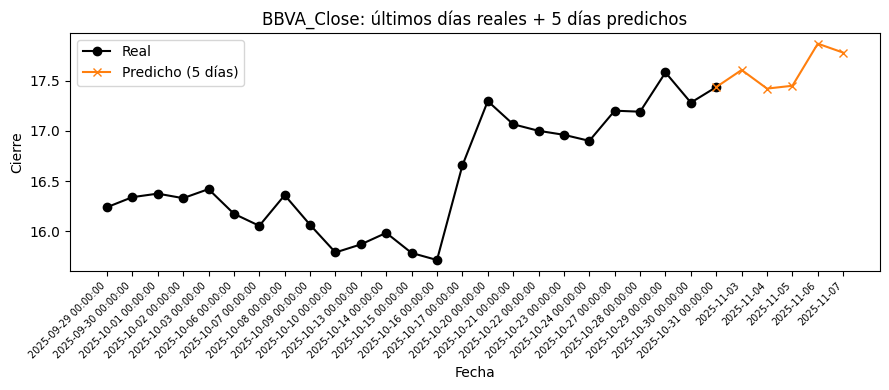

In [72]:
# cuántos días reales quieres enseñar antes de los 5 predichos
ultimos_reales_a_mostrar = 25   # + 5 predichos = 30 puntos en la gráfica

# nos quedamos con las últimas filas del df que ya tiene los futuros
df_plot = df_con_futuro.tail(ultimos_reales_a_mostrar + len(preds_futuro))

# índice para la gráfica
x = range(len(df_plot))

# columna de cierre
y = df_plot["BBVA_Close"].values

# posición donde empiezan los predichos (los 5 últimos)
idx_pred_start = len(df_plot) - len(preds_futuro)

plt.figure(figsize=(9,4))
# tramo real (todo menos los 5 últimos)
plt.plot(x[:idx_pred_start], y[:idx_pred_start], label="Real", color="black", marker="o")

# tramo predicho (los 5 últimos)
plt.plot(x[idx_pred_start-1:], y[idx_pred_start-1:], label="Predicho (5 días)", color="tab:orange", marker="x")

# opcional: poner las fechas en el eje x
fechas = df_plot["Date"].astype(str).tolist()
plt.xticks(x, fechas, rotation=45, ha="right", fontsize=7)

plt.title("BBVA_Close: últimos días reales + 5 días predichos")
plt.xlabel("Fecha")
plt.ylabel("Cierre")
plt.legend()
plt.tight_layout()
plt.show()
